In [1]:
import os
extracted_files=os.listdir('/content')
print(extracted_files)
folder_path='/content/fingerprints_dataset'
if os.path.exists(folder_path):
  print(f"{folder_path} exists")
import os
extracted_files=os.listdir('/content')
print(extracted_files)
folder_path='/content/fingerprints_dataset'
if os.path.exists(folder_path):
  print(f"{folder_path} exists")
  print(os.listdir(folder_path))
else:
  print(f"{folder_path} does not exist")

['fingerprints_dataset']
/content/fingerprints_dataset exists
['fingerprints_dataset']
/content/fingerprints_dataset exists
['dataset_blood_group']


In [2]:
import os

def check_files_in_directory(directory):
    for root, dirs, files in os.walk(directory):
        print(f"Checking folder: {root}")
        print(f"Files in {root}: {files}")
        if not files:
            print(f"No files found in {root}")

# Check all files in the dataset directory
check_files_in_directory('/content/fingerprints_dataset/dataset_blood_group')

Checking folder: /content/fingerprints_dataset/dataset_blood_group
Files in /content/fingerprints_dataset/dataset_blood_group: []
No files found in /content/fingerprints_dataset/dataset_blood_group
Checking folder: /content/fingerprints_dataset/dataset_blood_group\A+
Files in /content/fingerprints_dataset/dataset_blood_group\A+: ['cluster_0_1001.BMP', 'cluster_0_1005.BMP', 'cluster_0_1009.BMP', 'cluster_0_1026.BMP', 'cluster_0_1029.BMP', 'cluster_0_1036.BMP', 'cluster_0_1041.BMP', 'cluster_0_1045.BMP', 'cluster_0_1063.BMP', 'cluster_0_1075.BMP', 'cluster_0_1082.BMP', 'cluster_0_1087.BMP', 'cluster_0_1089.BMP', 'cluster_0_1118.BMP', 'cluster_0_1123.BMP', 'cluster_0_1126.BMP', 'cluster_0_1145.BMP', 'cluster_0_1153.BMP', 'cluster_0_116.BMP', 'cluster_0_1181.BMP', 'cluster_0_1183.BMP', 'cluster_0_1196.BMP', 'cluster_0_1210.BMP', 'cluster_0_1214.BMP', 'cluster_0_1217.BMP', 'cluster_0_1236.BMP', 'cluster_0_1247.BMP', 'cluster_0_1258.BMP', 'cluster_0_127.BMP', 'cluster_0_1293.BMP', 'cluster_0

In [3]:
import os

folder_path = '/content/fingerprints_dataset/dataset_blood_group'

# Check for specific file types (e.g., BMP files)
for label in os.listdir(folder_path):
    label_path = os.path.join(folder_path, label)
    if os.path.isdir(label_path):
        bmp_files = [f for f in os.listdir(label_path) if f.endswith('.BMP')]
        print(f"Files in {label} folder: {bmp_files[:5]}...")  # Display first 5 files as a sample

Files in A+ folder: ['cluster_0_1001.BMP', 'cluster_0_1005.BMP', 'cluster_0_1009.BMP', 'cluster_0_1026.BMP', 'cluster_0_1029.BMP']...
Files in A- folder: ['cluster_1_0.BMP', 'cluster_1_1.BMP', 'cluster_1_1000.BMP', 'cluster_1_1007.BMP', 'cluster_1_1008.BMP']...
Files in AB+ folder: ['cluster_4_100.BMP', 'cluster_4_1016.BMP', 'cluster_4_103.BMP', 'cluster_4_1030.BMP', 'cluster_4_1042.BMP']...
Files in AB- folder: ['cluster_5_1003.BMP', 'cluster_5_1013.BMP', 'cluster_5_1024.BMP', 'cluster_5_105.BMP', 'cluster_5_1052.BMP']...
Files in B+ folder: ['cluster_2_10.BMP', 'cluster_2_1006.BMP', 'cluster_2_1012.BMP', 'cluster_2_1021.BMP', 'cluster_2_1038.BMP']...
Files in B- folder: ['cluster_3_1017.BMP', 'cluster_3_1018.BMP', 'cluster_3_1032.BMP', 'cluster_3_1035.BMP', 'cluster_3_1050.BMP']...
Files in O+ folder: ['cluster_6_1004.BMP', 'cluster_6_1019.BMP', 'cluster_6_102.BMP', 'cluster_6_1023.BMP', 'cluster_6_1033.BMP']...
Files in O- folder: ['cluster_7_1002.BMP', 'cluster_7_1014.BMP', 'cluste

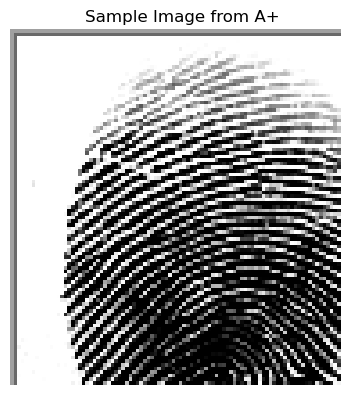

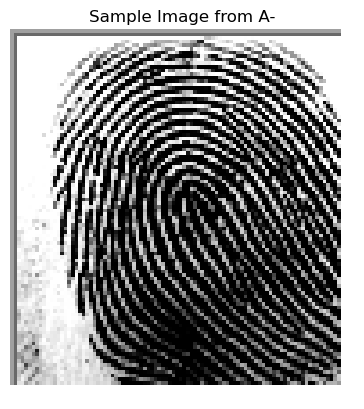

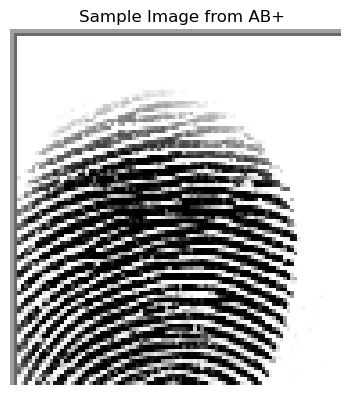

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Display some images from the dataset
folder_path = '/content/fingerprints_dataset/dataset_blood_group'
blood_groups = os.listdir(folder_path)

for blood_group in blood_groups[:3]:  # Check first 3 blood groups
    # Get a list of all files within the blood group folder
    files_in_blood_group = os.listdir(os.path.join(folder_path, blood_group))
    
    # Check if there are any files in the blood group folder
    if files_in_blood_group:
        # Use the first image file found
        img_path = os.path.join(folder_path, blood_group, files_in_blood_group[0])  
        
        # Read the image only if it's a valid image file
        if os.path.isfile(img_path) and img_path.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')): # Check if it's an image file
            img = mpimg.imread(img_path)
            plt.imshow(img)
            plt.title(f"Sample Image from {blood_group}")
            plt.axis('off')
            plt.show()
        else:
            print(f"No valid image file found in {blood_group} folder.")
    else:
        print(f"No files found in {blood_group} folder.")

In [5]:
import os
import glob
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics import classification_report

In [6]:
file_path = '/content/fingerprints_dataset/dataset_blood_group'

# List all classes in the dataset
name_class = os.listdir(file_path)
print(name_class)

['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']


In [7]:
# filepaths = list(glob.glob(file_path + '/*'))
filepaths = glob.glob(file_path + '/**/*.*', recursive=True) 
# Example of printing a subset of file paths
print(filepaths[-6:-1])

# Extract labels from file paths
labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))
print(labels)

['/content/fingerprints_dataset/dataset_blood_group\\O-\\cluster_7_964.BMP', '/content/fingerprints_dataset/dataset_blood_group\\O-\\cluster_7_977.BMP', '/content/fingerprints_dataset/dataset_blood_group\\O-\\cluster_7_979.BMP', '/content/fingerprints_dataset/dataset_blood_group\\O-\\cluster_7_985.BMP', '/content/fingerprints_dataset/dataset_blood_group\\O-\\cluster_7_998.BMP']
['A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 'A+', 

                                            Filepath Label
0  /content/fingerprints_dataset/dataset_blood_gr...    O+
1  /content/fingerprints_dataset/dataset_blood_gr...    A-
2  /content/fingerprints_dataset/dataset_blood_gr...   AB-
3  /content/fingerprints_dataset/dataset_blood_gr...    B-
4  /content/fingerprints_dataset/dataset_blood_gr...    A+


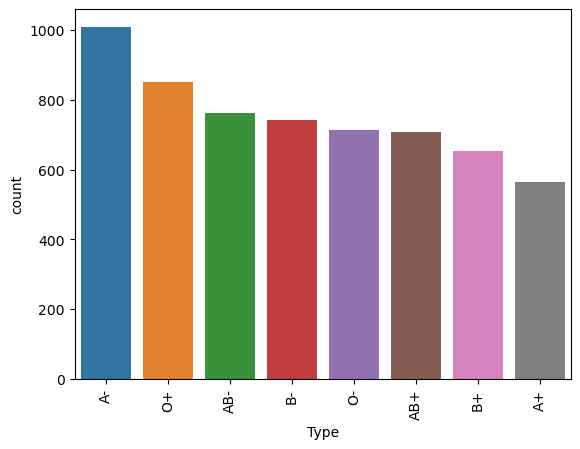

In [8]:
filepath = pd.Series(filepaths, name='Filepath').astype(str)
Labels = pd.Series(labels, name='Label')
data = pd.concat([filepath, Labels], axis=1)
data = data.sample(frac=1).reset_index(drop=True)
print(data.head(5))

# Visualize class distribution
counts = data.Label.value_counts()
sns.barplot(x=counts.index, y=counts)
plt.xlabel('Type')
plt.xticks(rotation=90)
plt.show()

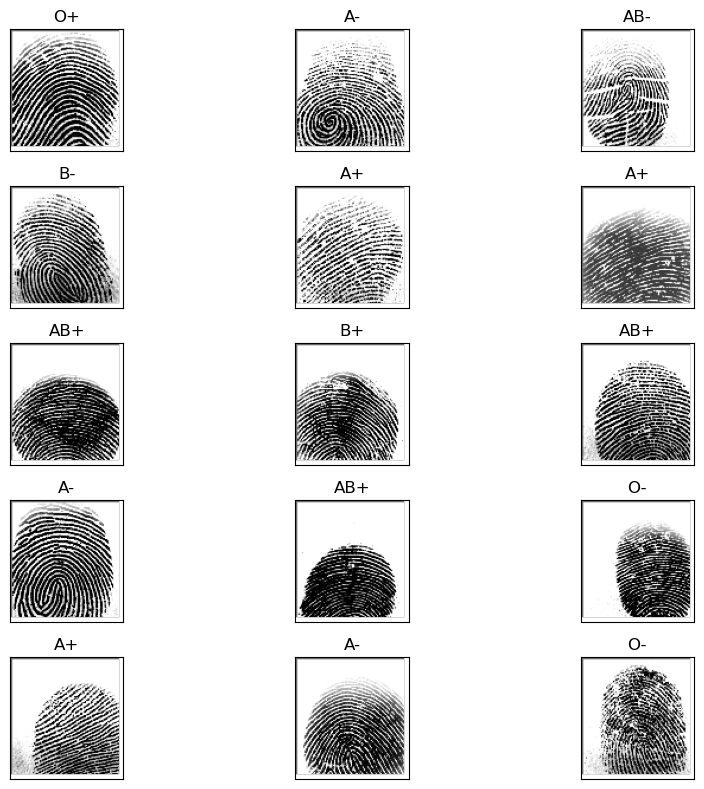

In [9]:
train, test = train_test_split(data, test_size=0.20, random_state=42)

# Visualize some images from the dataset
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(10, 8), subplot_kw={'xticks': [], 'yticks': []})
for i, ax in enumerate(axes.flat):
    # Check if the file exists and is an image before reading it
    if os.path.isfile(data.Filepath[i]) and data.Filepath[i].lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):  # Add other image extensions if needed
        ax.imshow(plt.imread(data.Filepath[i]))
        ax.set_title(data.Label[i])
    else:
        print(f"Skipping invalid file path: {data.Filepath[i]}")  # Print a message for skipped files
plt.tight_layout()
plt.show()

In [10]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train,
    x_col='Filepath',
    y_col='Label',
    target_size=(256, 256),
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42
)

valid_gen = train_datagen.flow_from_dataframe(
    dataframe=test,
    x_col='Filepath',
    y_col='Label',
    target_size=(256, 256),
    class_mode='categorical',
    batch_size=32,
    shuffle=False,
    seed=42
)

Found 4800 validated image filenames belonging to 8 classes.
Found 1200 validated image filenames belonging to 8 classes.


In [12]:
pretrained_model = ResNet50(
    input_shape=(256, 256, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

pretrained_model.trainable = True  # Unfreeze more layers
for layer in pretrained_model.layers[:-20]:  # Make last 20 layers trainable
    layer.trainable = False

from tensorflow.keras.layers import Dropout
x = Dense(128, activation="relu")(pretrained_model.output)
x = Dropout(0.2)(x)  # Reduce dropout to 20%
x = Dense(128, activation="relu")(x)
x = Dropout(0.2)(x)  # Reduce dropout to 20%
outputs = Dense(8, activation='softmax')(x)

model = Model(inputs=pretrained_model.input, outputs=outputs)

model.compile(
    optimizer="adam",
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler

# Define learning rate warm-up
def lr_warmup(epoch, lr):
    if epoch < 5:
        return lr * 1.2  # Increase LR in first 5 epochs
    return lr

optimizer = Adam(learning_rate=1e-4)  # Start with small LR

lr_scheduler = LearningRateScheduler(lr_warmup)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=40,  # Increase epochs
    callbacks=[lr_scheduler]
)

C:\Users\thiri\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 1597s 10s/step - accuracy: 0.3196 - loss: 1.7619 - val_accuracy: 0.4833 - val_loss: 1.2701 - learning_rate: 1.2000e-04
Epoch 2/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 1518s 10s/step - accuracy: 0.4728 - loss: 1.3133 - val_accuracy: 0.5908 - val_loss: 1.0853 - learning_rate: 1.4400e-04
Epoch 3/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 1507s 10s/step - accuracy: 0.6168 - loss: 0.9997 - val_accuracy: 0.6850 - val_loss: 0.8308 - learning_rate: 1.7280e-04
Epoch 4/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 1305s 9s/step - accuracy: 0.6761 - loss: 0.8939 - val_accuracy: 0.7267 - val_loss: 0.7530 - learning_rate: 2.0736e-04
Epoch 5/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 1337s 9s/step - accuracy: 0.7143 - loss: 0.7953 - val_accuracy: 0.7058 - val_loss: 0.7728 - learning_rate: 2.4883e-04
Epoch 6/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 1427s 10s/step - accuracy: 0.7271 - loss: 0.7439 - val_accuracy: 0.7475 - val_loss: 0.6642 - learning_rate: 2.4883e-04
Epoch 7/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 1364s 9s

In [14]:
# Save class indices (labels)
import json
with open("class_indices.json", "w") as f:
    json.dump(train_gen.class_indices, f)

print("Saved class indices:", train_gen.class_indices)

Saved class indices: {'A+': 0, 'A-': 1, 'AB+': 2, 'AB-': 3, 'B+': 4, 'B-': 5, 'O+': 6, 'O-': 7}


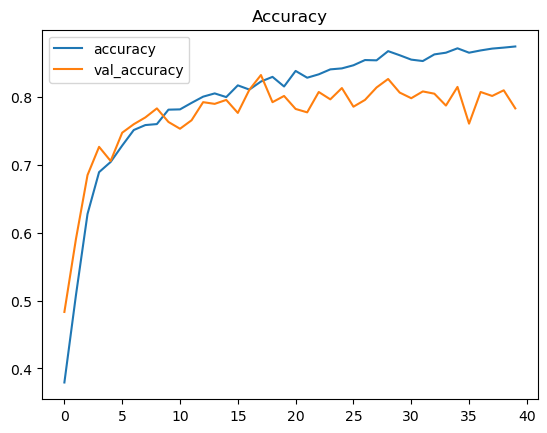

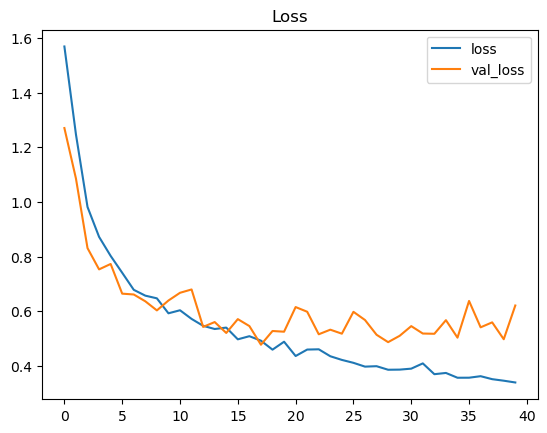

Test Loss: 0.57227
Test Accuracy: 80.33%
38/38 ━━━━━━━━━━━━━━━━━━━━ 248s 6s/step
              precision    recall  f1-score   support

          A+       0.73      0.94      0.82       121
          A-       0.87      0.65      0.74       199
         AB+       0.77      0.86      0.81       132
         AB-       0.77      0.72      0.75       149
          B+       0.77      0.79      0.78       118
          B-       0.79      0.97      0.87       152
          O+       0.91      0.74      0.82       189
          O-       0.72      0.76      0.74       140

    accuracy                           0.79      1200
   macro avg       0.79      0.80      0.79      1200
weighted avg       0.80      0.79      0.79      1200



In [15]:
# Plot training history: accuracy
pd.DataFrame(history.history)[['accuracy', 'val_accuracy']].plot()
plt.title("Accuracy")
plt.show()

# Plot training history: loss
pd.DataFrame(history.history)[['loss', 'val_loss']].plot()
plt.title("Loss")
plt.show()

# Evaluate the model on test data
results = model.evaluate(valid_gen, verbose=0)
print(f"Test Loss: {results[0]:.5f}")
print(f"Test Accuracy: {results[1]*100:.2f}%")

# Predict labels for test data
pred = model.predict(valid_gen)
pred = np.argmax(pred, axis=1)

# Map predicted labels
labels = train_gen.class_indices
labels = dict((v, k) for k, v in labels.items())
pred = [labels[k] for k in pred]

# Compare predicted labels with true labels and print classification report
y_test = list(test.Label)
print(classification_report(y_test, pred))

In [16]:
train_results = model.evaluate(train_gen, verbose=0)
print(f"Training Loss: {train_results[0]:.5f}")
print(f"Training Accuracy: {train_results[1] * 100:.2f}%")

# Evaluate on test data
test_results = model.evaluate(valid_gen, verbose=0)
print(f"Test Loss: {test_results[0]:.5f}")
print(f"Test Accuracy: {test_results[1] * 100:.2f}%")

Training Loss: 0.31688
Training Accuracy: 87.77%
Test Loss: 0.56551
Test Accuracy: 80.00%


In [17]:
model.save("model_blood_group_detection_3.h5")

In [18]:
train_gen.class_indices

{'A+': 0, 'A-': 1, 'AB+': 2, 'AB-': 3, 'B+': 4, 'B-': 5, 'O+': 6, 'O-': 7}

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


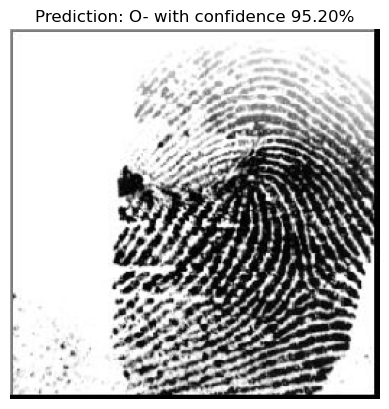

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.imagenet_utils import preprocess_input

# Load the pre-trained model
model = load_model('model_blood_group_detection_3.h5')

# Define the class labels
# labels = {'A+': 0, 'A-': 1, 'AB+': 2, 'AB-': 3, 'B+': 4, 'B-': 5, 'O+': 6, 'O-': 7}
# labels = dict((v, k) for k, v in labels.items())

with open("class_indices.json", "r") as f:
    labels = json.load(f)

# Reverse the dictionary to map indices to class labels
labels = {v: k for k, v in labels.items()}

# Example of loading a single image and making a prediction
# img_path = 'dataset_blood_group/A+/cluster_0_1001.BMP'

# img_path ='fingerprints_dataset.zip\fingerprints_dataset\dataset_blood_group\A+\cluster_0_1001.BMP'

# img_path='/content/fingerprints_dataset/dataset_blood_group/A+/cluster_0_1001.BMP'

img_path='/content/fingerprints_dataset/dataset_blood_group/O-/cluster_7_2.BMP'

img = image.load_img(img_path, target_size=(256, 256))  # Load the image
x = image.img_to_array(img)  # Convert image to array
x = np.expand_dims(x, axis=0)  # Expand dimensions to match the model input
x = preprocess_input(x)  # Preprocess the image

result = model.predict(x)  # Predict using the model
predicted_class = np.argmax(result)  # Get the predicted class index

# Map the predicted class to the label
predicted_label = labels[predicted_class]
confidence = result[0][predicted_class] * 100  # Confidence level

# Display the image
plt.imshow(image.array_to_img(image.img_to_array(img) / 255.0))
plt.axis('off')  # Hide axes

# Display the prediction and confidence below the image
plt.title(f"Prediction: {predicted_label} with confidence {confidence:.2f}%")
plt.show()